<a href="https://colab.research.google.com/github/Fernandateireis/dotfiles/blob/master/analises_descritivas_pnadc.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

PNAD Contínua — Análises Descritivas para Projeção Ocupacional
Projeto — Projeções de Força de Trabalho e Ocupações (Fernanda Teixeira Reis)
Objetivo: produzir as descritivas que servem de **insumo para o modelo preditivo** de curto prazo (**horizonte ~6 anos: 2025 → 2031**).
Blocos
**0** Qualidade e comparabilidade (missing por ano, N amostral × população)\n",
**1** Preparo de variáveis + **crosswalk oficial** família→grande grupo (validação contra `Estrutura_Ocupacao_COD`)\n",
**2** Séries temporais expandidas por grupo (alvos da projeção)\n",
**3** Segmentação (segregação por sexo/raça, gap salarial, formalidade, horas)\n",
**4** Mudança estrutural (share, envelhecimento, requalificação, digital)\n",
**5** Diagnósticos pré-modelagem (CAGR, correlação, coorte idade×ano)\n",
Premissas aplicadas
1. Renda (`VD4016`) **já vem deflacionada** (download via `PNADcIBGE`, base **2025**) — não há nova deflação aqui.\n",
2. **2020 e 2021** são marcados como atípicos (pandemia + 5ª visita) e excluídos do cálculo de tendências.\n",
3. Toda estatística populacional é **ponderada por `V1032`**.\n",
4. Com `VD4001` agora disponível, calculam-se **taxa de participação** e **taxa de ocupação**, além da desocupação.\n",
5. A análise por grupo é **parametrizada** (`GRUPO`): roda em grande grupo da COD ou no seu agrupamento Cuidados/STEM trocando uma variável.\n",
Por que ponderar tudo por `V1032`?
A PNADC é uma **amostra**, não um censo. Cada pessoa entrevistada representa um número de brasileiros — esse número é o peso.
O `V1032` é o peso já calibrado pelas projeções de população do IBGE. Sem ponderar, qualquer média ou contagem reflete a *amostra* (quem foi sorteado), não a *população*.
Por isso toda contagem usa soma de pesos e toda média usa média ponderada.\n"



Bibliotecas trabalhadas

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

Abrindo as pnads empilhadas: está no drive o parquet

---



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Caminho do arquivo DENTRO do Drive montado.

caminho = "/content/drive/MyDrive/Colab Notebooks/pnadc_2014_2025.parquet"
# Lê o parquet e guarda na variável df.
df = pd.read_parquet(caminho)

# Confirma o tamanho da tabela.
print("Linhas:", len(df), "  Colunas:", df.shape[1])

Linhas: 4979050   Colunas: 24


Converter Masculino -> homem e feminino -> mulher (anos 2014 e 2015

In [ ]:
# Converte a coluna de sexo para texto simples.
df["V2007"] = df["V2007"].astype(str)

# Unifica os rótulos: Masculino -> Homem, Feminino -> Mulher.
df["V2007"] = df["V2007"].replace({"Masculino": "Homem", "Feminino": "Mulher"})

# Confere: agora deve aparecer só "Homem" e "Mulher".
df["V2007"].value_counts()

,count
V2007,
Mulher,2553304
Homem,2425746


Vamos entender o banco

In [ ]:
# Mostra o nome de todas as colunas da tabela.
print(df.columns.tolist())

['Ano', 'UF', 'Estrato', 'V1022', 'V1023', 'V1032', 'V2007', 'V2009', 'V2010', 'VD3004', 'VD3005', 'V4010', 'V4013', 'V4019', 'V4040', 'VD4002', 'VD4016', 'VD4031', 'VD4035', 'V5001A', 'S01029', 'VD4001', 'VD4009', 'VD4012']


In [ ]:
# Mostra as 5 primeiras linhas, mas só de algumas colunas escolhidas.
df[["Ano", "V2007", "V2009", "VD4002", "V1032"]].head()

,Ano,V2007,V2009,VD4002,V1032
0,2014,Homem,42.0,Pessoas ocupadas,270.144765
1,2014,Mulher,39.0,Pessoas ocupadas,270.144765
2,2014,Homem,22.0,NaN,270.144765
3,2014,Homem,20.0,Pessoas ocupadas,270.144765
4,2014,Homem,7.0,NaN,270.144765


In [ ]:
# Mostra cada valor diferente que aparece na coluna VD4002 e quantas vezes aparece.
df["VD4002"].value_counts(dropna=False)

,count
VD4002,
NaN,2622612
Pessoas ocupadas,2137544
Pessoas desocupadas,218894


Vamos agrupar as linhas por ano e somar o peso de cada ano

Essa tabela passou no teste de sanidade. A população sai de ~200,2 milhões em 2014 e cresce suavemente até ~212,7 milhões em 2025 — exatamente a trajetória que o IBGE projeta para o Brasil, sem nenhum salto estranho entre anos. Isso confirma três coisas de uma vez: o parquet está íntegro, o peso V1032 está correto, e a soma ponderada está funcionando. A base está sólida e podemos confiar nela.

In [ ]:
# ["V1032"] escolhe a coluna do peso.
pessoas_por_ano = df.groupby("Ano")["V1032"].sum()

pessoas_por_ano

,V1032
Ano,
2014,2.001889e+08
2015,2.017696e+08
2016,2.032265e+08
2017,2.045549e+08
2018,2.058599e+08
2019,2.072173e+08
2020,2.084698e+08
2021,2.093985e+08
2022,2.101473e+08


Ocupados por ano: mesma soma de pesos, mas filtrando só quem está ocupado.

 A ocupação fica em torno de 90-93 milhões até 2019, despenca para 85,3 milhões em 2020 (a pandemia!!!!), começa a se recuperar em 2021, e a partir de 2022 dá um salto consistente até quase 103 milhões em 2025. O padrão está lógico: o "buraco" de 2020 aparece nítido, e o crescimento pós-2022 é real.

In [ ]:
# Passo 1: separar só as pessoas ocupadas.
# O resultado (ocupados) é uma tabela só com quem trabalha.
ocupados = df[df["VD4002"] == "Pessoas ocupadas"]

# Passo 2: agrupar por ano e somar o peso = total de ocupados por ano.
ocupados_por_ano = ocupados.groupby("Ano")["V1032"].sum()

# Passo 3: mostrar, já dividido por 1 milhão para ficar legível.
ocupados_por_ano / 1000000

,V1032
Ano,
2014,91.619468
2015,91.649114
2016,89.893719
2017,90.172058
2018,91.519377
2019,93.534214
2020,85.289462
2021,87.929491
2022,97.718822


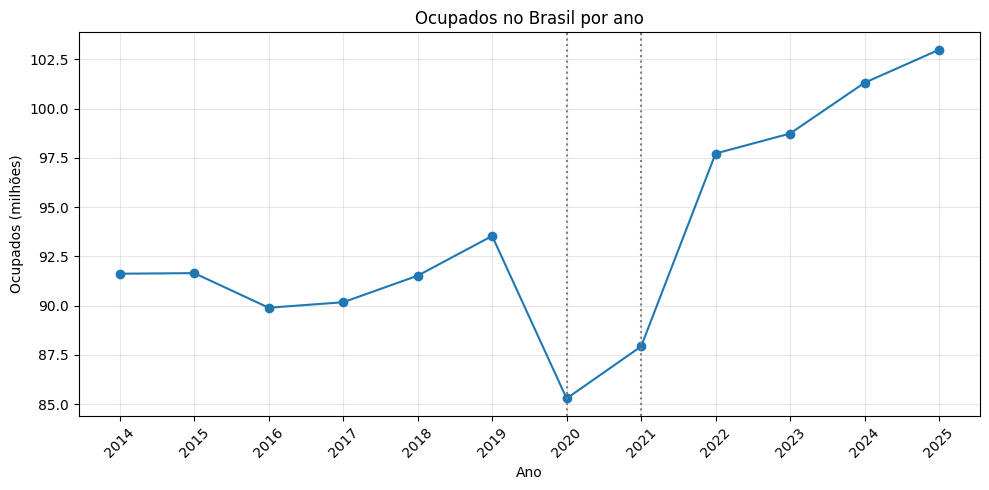

In [ ]:
# Reaproveita a série de ocupados em milhões.
serie = ocupados_por_ano / 1000000

# CORREÇÃO: garante que os anos (o índice da série) sejam números inteiros.
serie.index = serie.index.astype(int)

# Ordena pelos anos, do menor para o maior (garante a ordem certa na linha).
serie = serie.sort_index()

# Deixa a figura num tamanho confortável (largura, altura).
plt.figure(figsize=(10, 5))

# Desenha a linha com uma bolinha em cada ano.
plt.plot(serie.index, serie.values, marker="o")

# Título e nomes dos eixos.
plt.title("Ocupados no Brasil por ano")
plt.ylabel("Ocupados (milhões)")
plt.xlabel("Ano")

# Mostra um rótulo para cada ano no eixo de baixo (sem amontoar).
plt.xticks(serie.index, rotation=45)

# Linhas pontilhadas nos anos atípicos.
plt.axvline(2020, color="grey", linestyle=":")
plt.axvline(2021, color="grey", linestyle=":")

# Grade leve ao fundo, ajuda a ler os valores.
plt.grid(alpha=0.3)

# Ajusta o layout e mostra.
plt.tight_layout()
plt.show()

POr sexo

In [ ]:
# Separa só os ocupados (texto exato que vimos antes).
ocupados = df[df["VD4002"] == "Pessoas ocupadas"]

# Agrupa por ano E por sexo ao mesmo tempo, e soma o peso.
ocupados_sexo = ocupados.groupby(["Ano", "V2007"])["V1032"].sum()

# Reorganiza para tabela: anos nas linhas, sexo nas colunas.
tabela_sexo = ocupados_sexo.unstack()

# Converte para milhões.
tabela_sexo = tabela_sexo / 1000000

# Mostra.
tabela_sexo

V2007,Homem,Mulher
Ano,,
2014,53.095460,38.524008
2015,53.018118,38.630996
2016,51.751679,38.142040
2017,51.762795,38.409263
2018,52.203584,39.315793
2019,53.442240,40.091974
2020,49.587785,35.701677
2021,51.327012,36.602479
2022,55.746535,41.972287


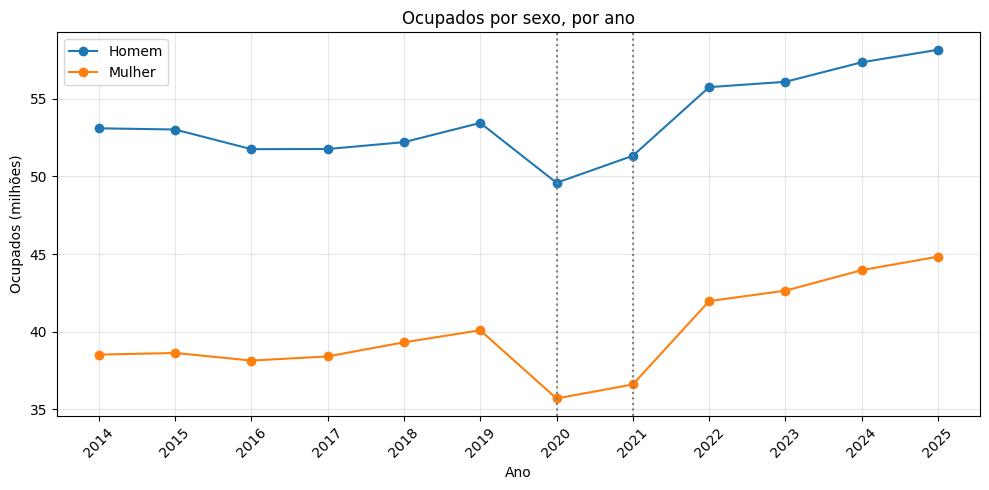

In [ ]:
# Garante anos como número inteiro e em ordem.
tabela_sexo.index = tabela_sexo.index.astype(int)
tabela_sexo = tabela_sexo.sort_index()

# Tamanho da figura.
plt.figure(figsize=(10, 5))

# Uma linha para cada sexo.
plt.plot(tabela_sexo.index, tabela_sexo["Homem"], marker="o", label="Homem")
plt.plot(tabela_sexo.index, tabela_sexo["Mulher"], marker="o", label="Mulher")

# Rótulos.
plt.title("Ocupados por sexo, por ano")
plt.ylabel("Ocupados (milhões)")
plt.xlabel("Ano")

# Um rótulo por ano.
plt.xticks(tabela_sexo.index, rotation=45)

# Anos atípicos.
plt.axvline(2020, color="grey", linestyle=":")
plt.axvline(2021, color="grey", linestyle=":")

# Legenda (usa os 'label' de cada linha) e grade.
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

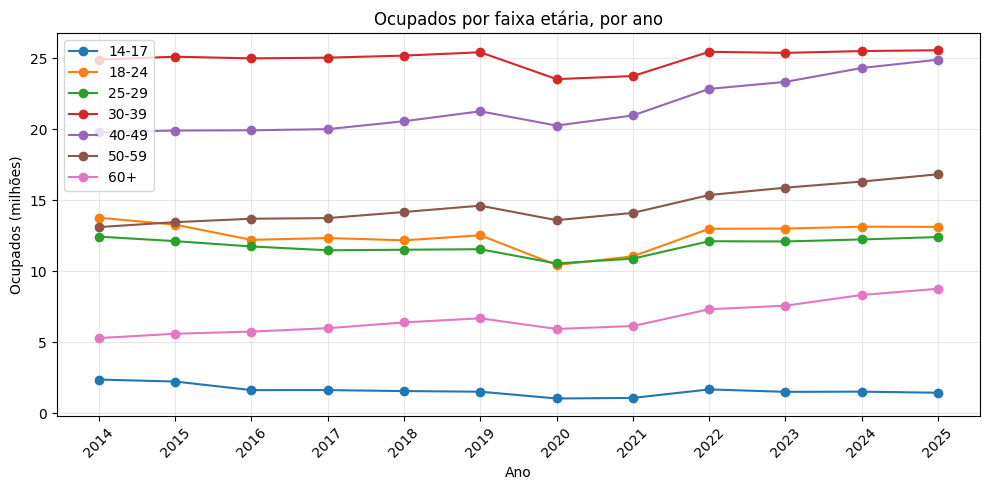

In [ ]:
# Cria faixas a partir da idade (V2009). pd.cut corta a idade nos limites dados.
# A borda esquerda é exclusiva: 13 garante que 14 anos caia em '14-17'.
faixas = pd.cut(ocupados["V2009"],
                bins=[13, 17, 24, 29, 39, 49, 59, 200],
                labels=["14-17", "18-24", "25-29", "30-39", "40-49", "50-59", "60+"])

# Soma o peso por ano e faixa, abre em tabela, passa para milhões.
tab_idade = ocupados.groupby(["Ano", faixas], observed=True)["V1032"].sum()
tab_idade = tab_idade.unstack()
tab_idade = tab_idade / 1000000

tab_idade.index = tab_idade.index.astype(int)
tab_idade = tab_idade.sort_index()

plt.figure(figsize=(10, 5))
for coluna in tab_idade.columns:
    plt.plot(tab_idade.index, tab_idade[coluna], marker="o", label=coluna)

plt.title("Ocupados por faixa etária, por ano")
plt.ylabel("Ocupados (milhões)")
plt.xlabel("Ano")
plt.xticks(tab_idade.index, rotation=45)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

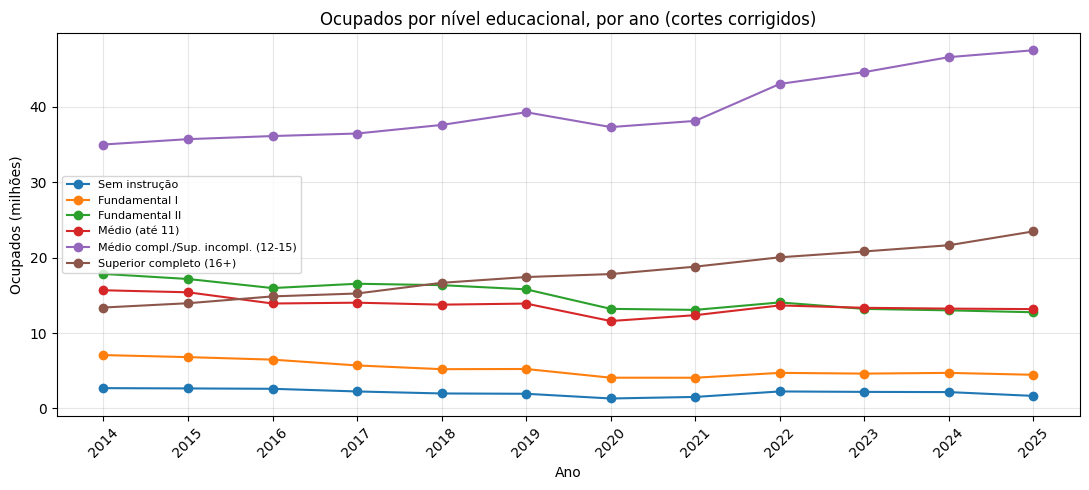

In [ ]:
ocupados = df[df["VD4002"] == "Pessoas ocupadas"]

# Extrai o número de anos de estudo de dentro do texto.
anos_estudo = ocupados["VD3005"].str.extract(r"(\d+)")
anos_estudo = anos_estudo[0].astype(float)

# Trata o "Sem instrução" explicitamente: onde o texto começa com "Sem", força 0.
sem_instrucao = ocupados["VD3005"].str.startswith("Sem")
anos_estudo[sem_instrucao.values] = 0

# Cortes corrigidos para o sistema brasileiro.
# 0 = sem instrução | 1-4 fundamental I | 5-8 fundamental II
# 9-11 médio incompleto | 12-15 médio completo/superior incompleto | 16+ superior completo
nivel = pd.cut(anos_estudo,
               bins=[-1, 0, 4, 8, 11, 15, 100],
               labels=["Sem instrução", "Fundamental I", "Fundamental II",
                       "Médio (até 11)", "Médio compl./Sup. incompl. (12-15)",
                       "Superior completo (16+)"])

tab_educ = ocupados.groupby(["Ano", nivel], observed=True)["V1032"].sum()
tab_educ = tab_educ.unstack()
tab_educ = tab_educ / 1000000
tab_educ.index = tab_educ.index.astype(int)
tab_educ = tab_educ.sort_index()

plt.figure(figsize=(11, 5))
for coluna in tab_educ.columns:
    plt.plot(tab_educ.index, tab_educ[coluna], marker="o", label=coluna)
plt.title("Ocupados por nível educacional, por ano (cortes corrigidos)")
plt.ylabel("Ocupados (milhões)")
plt.xlabel("Ano")
plt.xticks(tab_educ.index, rotation=45)
plt.legend(fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

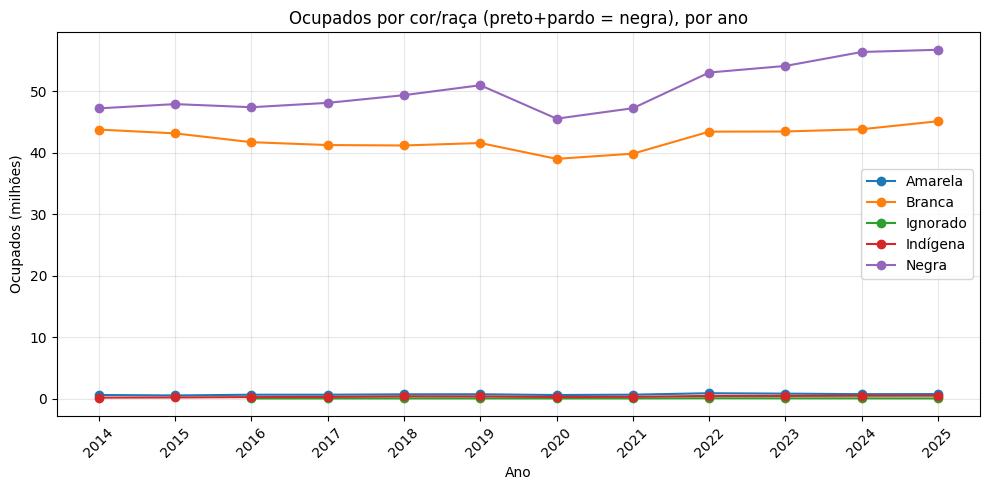

In [ ]:
ocupados = df[df["VD4002"] == "Pessoas ocupadas"]

# Cria uma cópia da coluna de raça para agrupar sem mexer no original.
raca = ocupados["V2010"].astype(str)

# Junta Preta + Parda numa única categoria "Negra".
raca = raca.replace({"Preta": "Negra", "Parda": "Negra"})

# Agrupa por ano e por essa raça já recodificada, soma o peso.
tab_raca = ocupados.groupby(["Ano", raca], observed=True)["V1032"].sum()
tab_raca = tab_raca.unstack() / 1000000
tab_raca.index = tab_raca.index.astype(int)
tab_raca = tab_raca.sort_index()

plt.figure(figsize=(10, 5))
for coluna in tab_raca.columns:
    plt.plot(tab_raca.index, tab_raca[coluna], marker="o", label=coluna)
plt.title("Ocupados por cor/raça (preto+pardo = negra), por ano")
plt.ylabel("Ocupados (milhões)")
plt.xlabel("Ano")
plt.xticks(tab_raca.index, rotation=45)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
ocupados = df[df["VD4002"] == "Pessoas ocupadas"]

# Lista com os rótulos EXATOS de VD4009 que contam como FORMAL.
# Ajuste os textos conforme o que apareceu no value_counts acima.
formais_labels = [
    "Empregado no setor privado com carteira de trabalho assinada",
    "Trabalhador doméstico com carteira de trabalho assinada",
    "Militar do exército, marinha, aeronáutica, policia ou bombeiro militar",
    "Empregado no setor público com carteira de trabalho assinada",
    "Servidor estatutário",
]

# Cria uma coluna nova: "Formal" se o rótulo está na lista, senão "Informal".
ocupados = ocupados.copy()
ocupados["formalidade"] = "Informal"
eh_formal = ocupados["VD4009"].isin(formais_labels)
ocupados.loc[eh_formal, "formalidade"] = "Formal"

# Soma o peso por ano e por formalidade, abre em tabela, em milhões.
tab_form = ocupados.groupby(["Ano", "formalidade"], observed=True)["V1032"].sum()
tab_form = tab_form.unstack() / 1000000
tab_form.index = tab_form.index.astype(int)
tab_form = tab_form.sort_index()

tab_form.round(2)

formalidade,Formal,Informal
Ano,,
2014,39.98,51.64
2015,39.38,52.27
2016,37.62,52.28
2017,36.37,53.80
2018,36.15,55.37
2019,37.02,56.51
2020,34.49,50.80
2021,34.36,53.57
2022,38.17,59.54


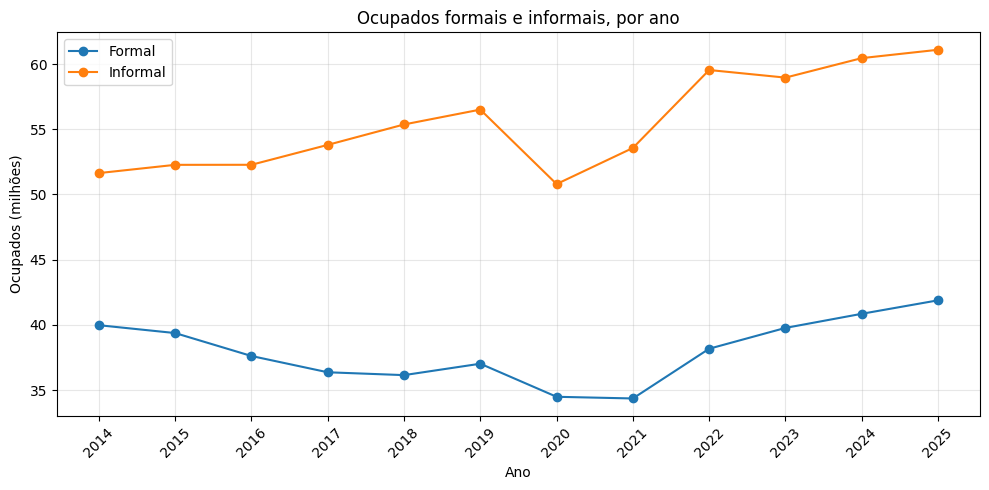

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
for coluna in tab_form.columns:
    plt.plot(tab_form.index, tab_form[coluna], marker="o", label=coluna)
plt.title("Ocupados formais e informais, por ano")
plt.ylabel("Ocupados (milhões)")
plt.xlabel("Ano")
plt.xticks(tab_form.index, rotation=45)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

A VD4009 tem 10 categorias (fora o NaN, que são os não-ocupados). As claramente formais são as quatro com carteira/estatutário. As claramente informais são as sem carteira, doméstico sem carteira e trabalhador familiar auxiliar. O problema está em três categorias ambíguas: conta-própria, empregador e empregado público sem carteira.

A convenção mais aceita na literatura brasileira (IBGE/IPEA) trata assim:
Conta-própria e empregador são formais só se contribuem para a previdência — e é exatamente para isso que serve a VD4012 que você incluiu na nova extração. Sem ela, o critério usual é considerá-los informais (a maioria do conta-própria brasileiro é informal). O empregado público sem carteira (estatutário não, mas contratos precários) costuma entrar como informal.

Como a VD4012 já está no parquet (veio nesta extração), o ideal é usar a definição completa: formal = tem carteira/estatutário OU (conta-própria/empregador que contribui para a previdência).

In [ ]:
# Se aparecer a contagem por categorias, a variável já está no parquet.
# Se der erro de coluna inexistente, a extração nova ainda não foi carregada.
print(df["VD4009"].value_counts(dropna=False))



VD4009
NaN                                                             2841506
Empregado no setor privado com carteira de trabalho assinada     683466
Conta-própria                                                    593990
Empregado no setor privado sem carteira de trabalho assinada     278168
Militar e servidor estatutário                                   184868
Trabalhador doméstico sem carteira de trabalho assinada           99879
Empregador                                                        88746
Trabalhador familiar auxiliar                                     72709
Empregado no setor público sem carteira de trabalho assinada      71732
Trabalhador doméstico com carteira de trabalho assinada           36815
Empregado no setor público com carteira de trabalho assinada      27171
Name: count, dtype: int64


A boa notícia metodológica: muitos estudos usam a contribuição previdenciária como a definição de formalidade, sozinha — é objetiva, comparável e resolve o problema do conta-própria sem achismo. Formal = contribui; informal = não contribui. Vou usar essa, que é a mais defensável e a mais simples.

In [ ]:
ocupados = df[df["VD4002"] == "Pessoas ocupadas"].copy()

# FORMALIDADE pela contribuição previdenciária (definição objetiva).
ocupados["formalidade"] = "Informal"
eh_formal = ocupados["VD4012"] == "Contribuinte"
ocupados.loc[eh_formal, "formalidade"] = "Formal"

# Raça: preto + pardo = Negra.
ocupados["raca"] = ocupados["V2010"].astype(str)
ocupados["raca"] = ocupados["raca"].replace({"Preta": "Negra", "Parda": "Negra"})

# Só informais.
informais = ocupados[ocupados["formalidade"] == "Informal"]

tab_inf_raca = informais.groupby(["Ano", "raca"], observed=True)["V1032"].sum()
tab_inf_raca = tab_inf_raca.unstack() / 1000000
tab_inf_raca.index = tab_inf_raca.index.astype(int)
tab_inf_raca = tab_inf_raca.sort_index()

tab_inf_raca.round(2)

raca,Amarela,Branca,Ignorado,Indígena,Negra
Ano,,,,,
2014,0.14,12.05,NaN,0.06,19.74
2015,0.13,11.72,NaN,0.08,19.86
2016,0.16,11.36,0.00,0.11,19.54
2017,0.19,12.04,0.00,0.12,20.33
2018,0.21,12.21,0.00,0.16,21.06
2019,0.23,12.44,0.01,0.17,21.77
2020,0.17,10.70,0.01,0.11,18.54
2021,0.19,11.30,0.01,0.13,19.95
2022,0.28,12.66,0.01,0.19,22.40


In [ ]:
print(df["VD4012"].value_counts(dropna=False))

VD4012
NaN                 2841506
Contribuinte        1269522
Não contribuinte     868022
Name: count, dtype: int64


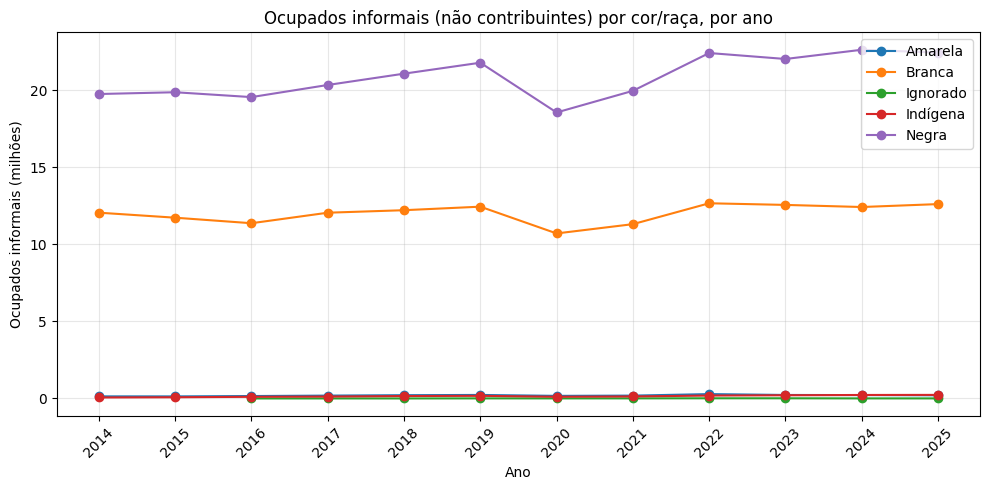

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
for coluna in tab_inf_raca.columns:
    plt.plot(tab_inf_raca.index, tab_inf_raca[coluna], marker="o", label=coluna)
plt.title("Ocupados informais (não contribuintes) por cor/raça, por ano")
plt.ylabel("Ocupados informais (milhões)")
plt.xlabel("Ano")
plt.xticks(tab_inf_raca.index, rotation=45)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt

ocupados = df[df["VD4002"] == "Pessoas ocupadas"].copy()

# Formalidade pela contribuição previdenciária.
ocupados["formalidade"] = "Informal"
eh_formal = ocupados["VD4012"] == "Contribuinte"
ocupados.loc[eh_formal, "formalidade"] = "Formal"

# Padroniza o sexo (Masculino/Feminino dos anos antigos -> Homem/Mulher).
ocupados["V2007"] = ocupados["V2007"].astype(str)
ocupados["V2007"] = ocupados["V2007"].replace({"Masculino": "Homem", "Feminino": "Mulher"})

# Agrupa por ano, sexo E formalidade ao mesmo tempo, soma o peso.
tab = ocupados.groupby(["Ano", "V2007", "formalidade"], observed=True)["V1032"].sum()

# Abre em tabela: anos nas linhas; nas colunas, cada combinação sexo+formalidade.
tab = tab.unstack(["V2007", "formalidade"]) / 1000000
tab.index = tab.index.astype(int)
tab = tab.sort_index()

tab.round(2)

V2007        Homem          Mulher         
formalidade Formal Informal Formal Informal
Ano                                        
2014         34.22    18.87  25.41    13.12
2015         34.25    18.77  25.61    13.02
2016         33.24    18.51  25.48    12.66
2017         32.41    19.35  25.08    13.33
2018         32.51    19.70  25.37    13.94
2019         33.18    20.26  25.74    14.35
2020         31.81    17.78  23.95    11.75
2021         32.22    19.11  24.13    12.47
2022         34.94    20.81  27.24    14.73
2023         35.57    20.52  28.15    14.49
2024         36.56    20.78  29.27    14.69
2025         37.39    20.76  30.11    14.72

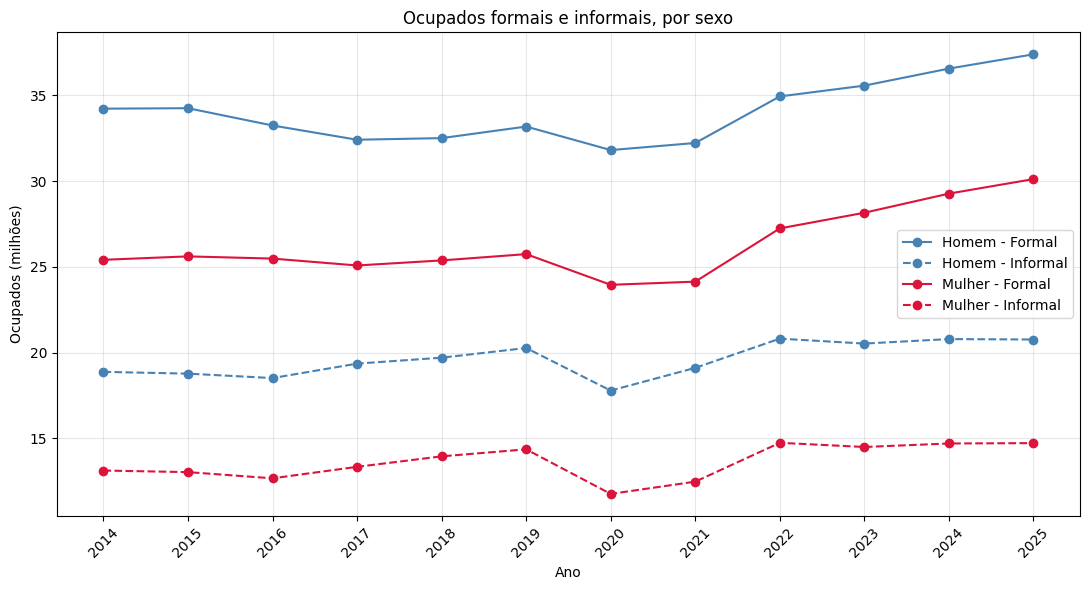

In [ ]:
plt.figure(figsize=(11, 6))

# Cada linha: escolhe a combinação, define cor (sexo) e traço (formalidade).
plt.plot(tab.index, tab[("Homem", "Formal")],   marker="o", color="steelblue", linestyle="-",  label="Homem - Formal")
plt.plot(tab.index, tab[("Homem", "Informal")], marker="o", color="steelblue", linestyle="--", label="Homem - Informal")
plt.plot(tab.index, tab[("Mulher", "Formal")],   marker="o", color="crimson",   linestyle="-",  label="Mulher - Formal")
plt.plot(tab.index, tab[("Mulher", "Informal")], marker="o", color="crimson",   linestyle="--", label="Mulher - Informal")

plt.title("Ocupados formais e informais, por sexo")
plt.ylabel("Ocupados (milhões)")
plt.xlabel("Ano")
plt.xticks(tab.index, rotation=45)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()